In [27]:
import os
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def get_relaxation_time(f, t):
    tau = np.interp(1 / np.e, f[::-1], t[::-1])
    if not np.min(f) < 1 / np.e:
        return np.nan
    return tau

root = '/Users/marshallmccraw/Projects/yale/data/s-26/grant/ga-data'
dynamics_data = np.load(os.path.join(root, 'ga-dynamics-data-4.npz'))
jamming_data = np.load(os.path.join(root, 'ga-jamming-data.npz'))

mu_norm = LogNorm(min(dynamics_data['mu']), max(dynamics_data['mu']))
alpha_norm = plt.Normalize(min(dynamics_data['alpha']), max(dynamics_data['alpha']))
cmap = plt.cm.viridis

In [28]:
tau_df = {
    'alpha': [],
    'mu': [],
    'phi': [],
    'tau': [],
    'tau_r': [],
}
for alpha in np.unique(dynamics_data['alpha']):
    for mu in np.unique(dynamics_data['mu']):
        mask = (dynamics_data['mu'] == mu) & (dynamics_data['alpha'] == alpha)
        for isf, aisf, t, phi in zip(
            dynamics_data['isf_small'][mask],
            dynamics_data['aisf_small'][mask],
            dynamics_data['t'][mask],
            dynamics_data['phi'][mask]
        ):
            tau_df['tau'].append(get_relaxation_time(isf, t))
            tau_df['tau_r'].append(get_relaxation_time(aisf, t))
            tau_df['phi'].append(phi)
            tau_df['alpha'].append(alpha)
            tau_df['mu'].append(mu)
tau_df = pd.DataFrame(tau_df)

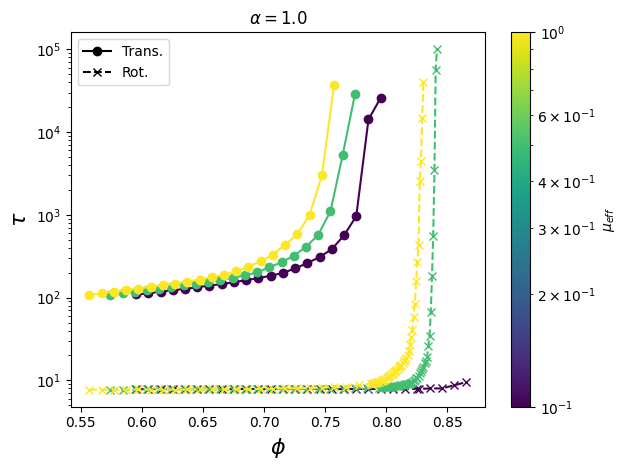

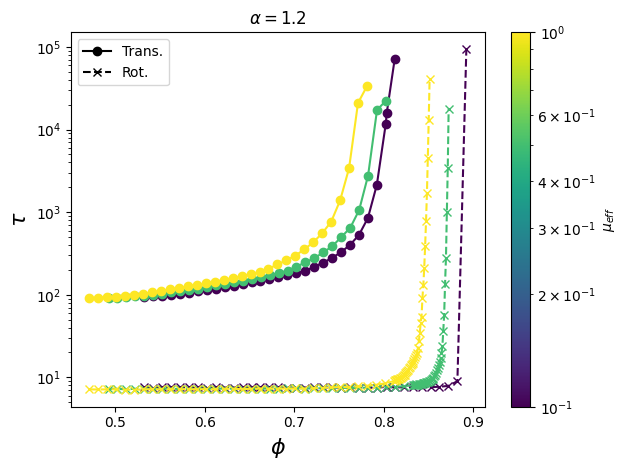

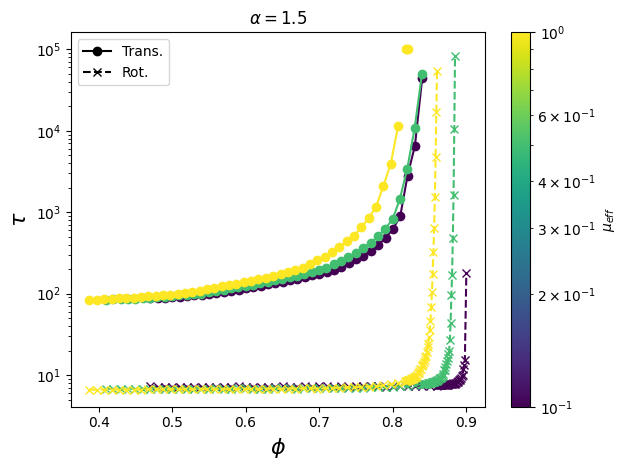

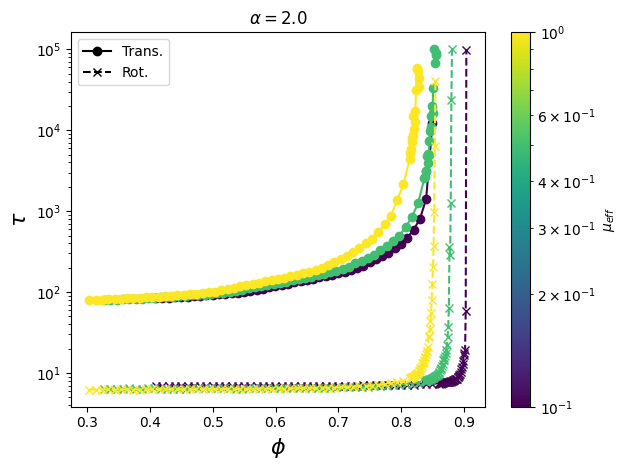

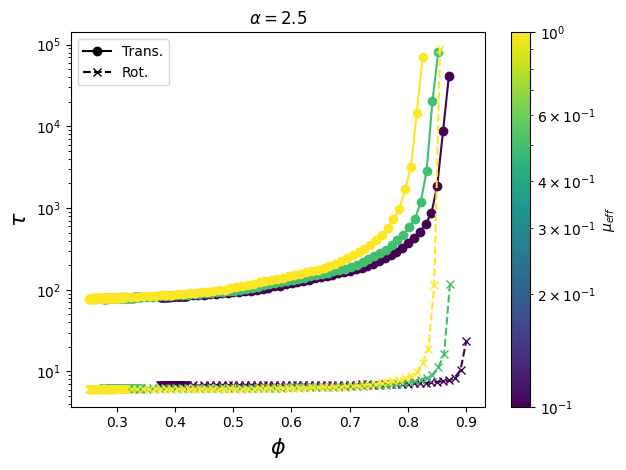

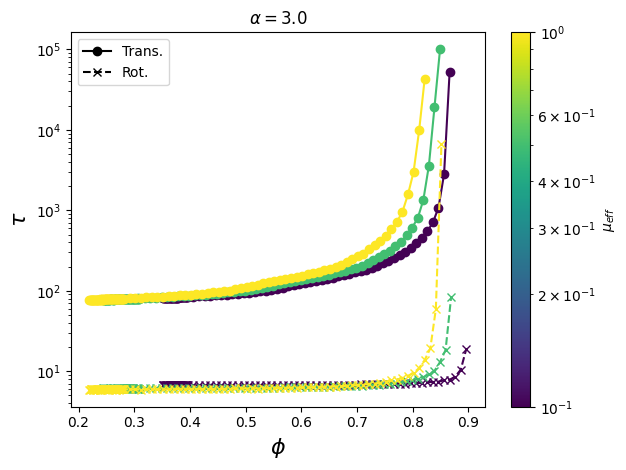

In [70]:
for alpha in pd.unique(tau_df.alpha):
    for mu in pd.unique(tau_df.mu):
        mask = (tau_df.alpha == alpha) & (tau_df.mu == mu)
        x = tau_df[mask].phi.values
        order = np.argsort(x)
        y = tau_df[mask].tau.values[order]
        y_r = tau_df[mask].tau_r.values[order]
        x = np.sort(x)
        plt.plot(x, y, c=cmap(mu_norm(mu)), marker='o')
        plt.plot(x, y_r, c=cmap(mu_norm(mu)), marker='x', linestyle='--')
    plt.plot([], [], marker='o', label='Trans.', c='k')
    plt.plot([], [], marker='x', linestyle='--', label='Rot.', c='k')
    plt.legend()
    plt.xlabel(r'$\phi$', fontsize=16)
    plt.ylabel(r'$\tau$', fontsize=16)
    plt.yscale('log')
    plt.title(fr'$\alpha=${alpha}')
    sm = plt.cm.ScalarMappable(norm=mu_norm, cmap=cmap)
    sm.set_array(pd.unique(tau_df.mu))
    cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\mu_{eff}$')
    plt.tight_layout()
    plt.show()

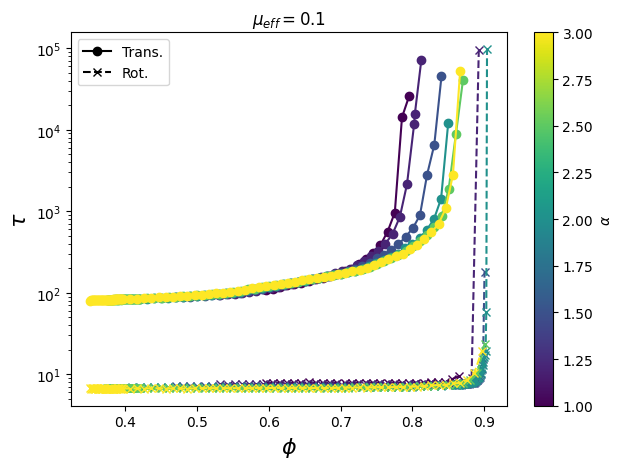

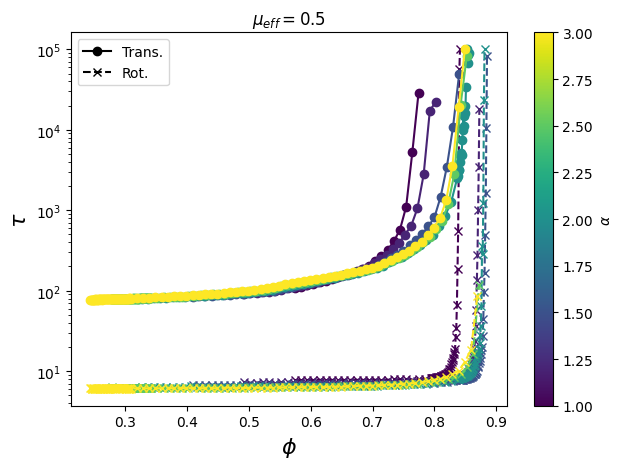

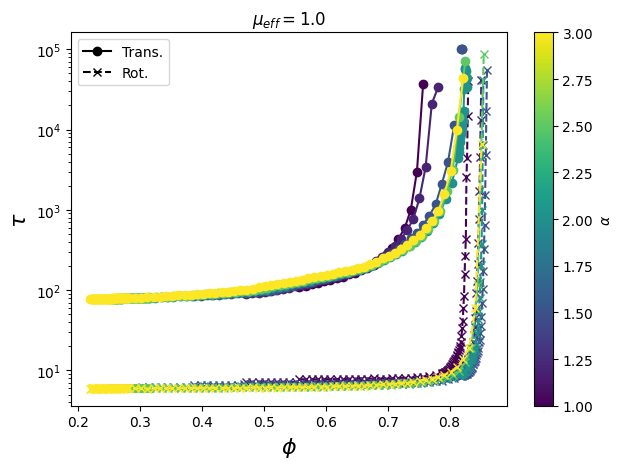

In [77]:
for mu in pd.unique(tau_df.mu):
    for alpha in pd.unique(tau_df.alpha):
        mask = (tau_df.alpha == alpha) & (tau_df.mu == mu)
        x = tau_df[mask].phi.values
        order = np.argsort(x)
        y = tau_df[mask].tau.values[order]
        y_r = tau_df[mask].tau_r.values[order]
        x = np.sort(x)
        plt.plot(x, y, c=cmap(alpha_norm(alpha)), marker='o')
        plt.plot(x, y_r, c=cmap(alpha_norm(alpha)), marker='x', linestyle='--')
    plt.plot([], [], marker='o', label='Trans.', c='k')
    plt.plot([], [], marker='x', linestyle='--', label='Rot.', c='k')
    plt.legend()
    plt.xlabel(r'$\phi$', fontsize=16)
    plt.ylabel(r'$\tau$', fontsize=16)
    plt.yscale('log')
    plt.title(fr'$\mu_{{eff}}=${mu}')
    sm = plt.cm.ScalarMappable(norm=alpha_norm, cmap=cmap)
    sm.set_array(pd.unique(tau_df.alpha))
    cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\alpha$')
    plt.tight_layout()
    plt.show()

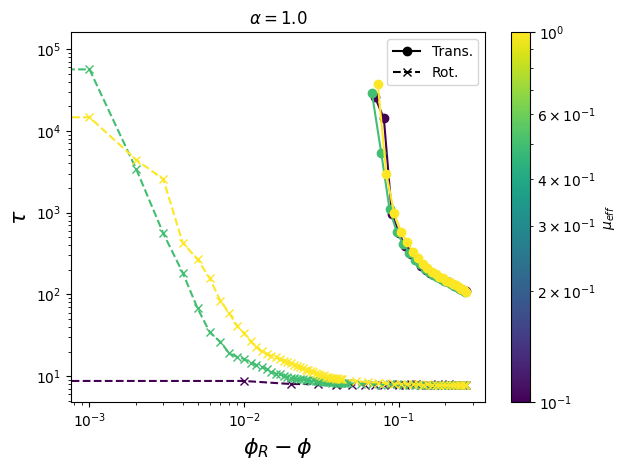

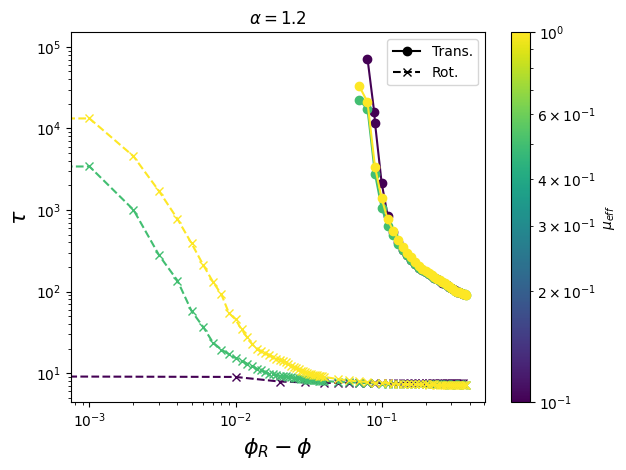

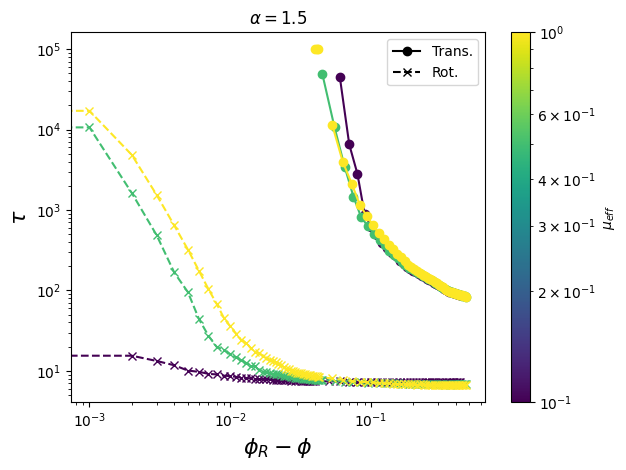

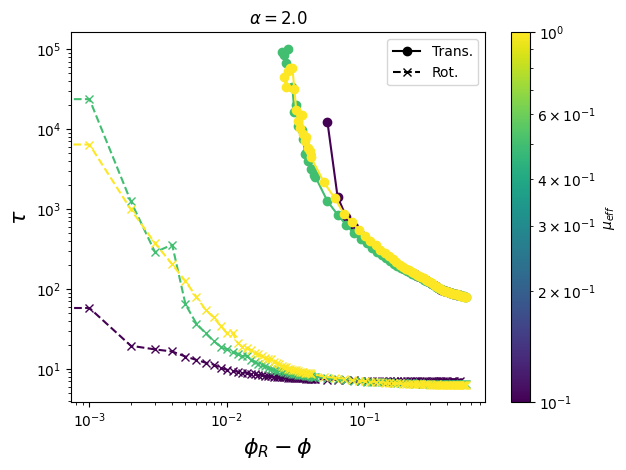

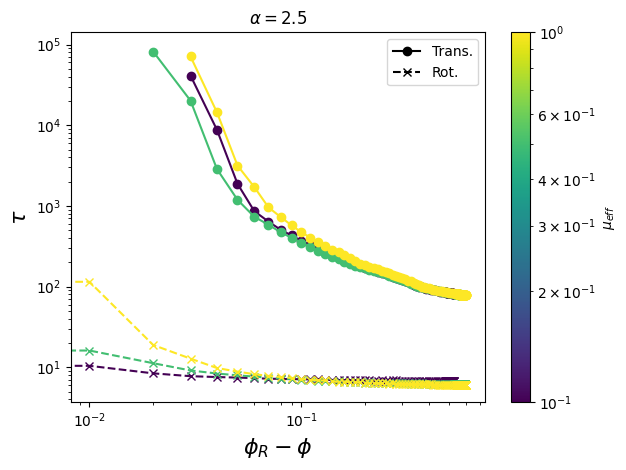

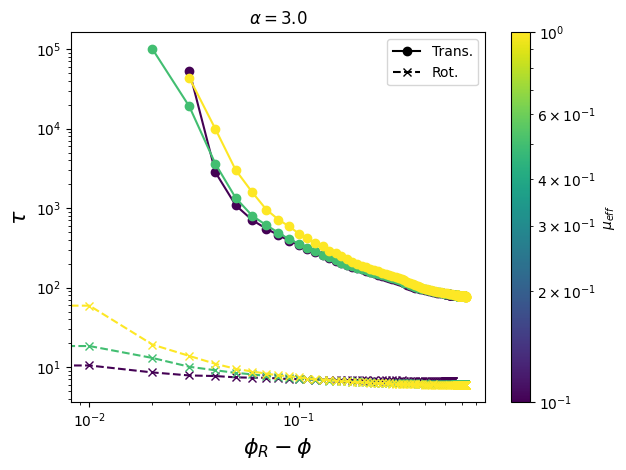

In [81]:
for alpha in pd.unique(tau_df.alpha):
    for mu in pd.unique(tau_df.mu):
        mask = (tau_df.alpha == alpha) & (tau_df.mu == mu)
        x = tau_df[mask].phi.values
        order = np.argsort(x)
        y = tau_df[mask].tau.values[order]
        y_r = tau_df[mask].tau_r.values[order]
        x = np.sort(x)
        x_r = x[np.nanargmax(y_r)]
        plt.plot(x_r - x, y, c=cmap(mu_norm(mu)), marker='o')
        plt.plot(x_r - x, y_r, c=cmap(mu_norm(mu)), marker='x', linestyle='--')
    plt.plot([], [], marker='o', label='Trans.', c='k')
    plt.plot([], [], marker='x', linestyle='--', label='Rot.', c='k')
    plt.legend()
    plt.xlabel(r'$\phi_R - \phi$', fontsize=16)
    plt.ylabel(r'$\tau$', fontsize=16)
    plt.xscale('log')
    plt.yscale('log')
    plt.title(fr'$\alpha=${alpha}')
    sm = plt.cm.ScalarMappable(norm=mu_norm, cmap=cmap)
    sm.set_array(pd.unique(tau_df.mu))
    cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\mu_{eff}$')
    plt.tight_layout()
    plt.show()

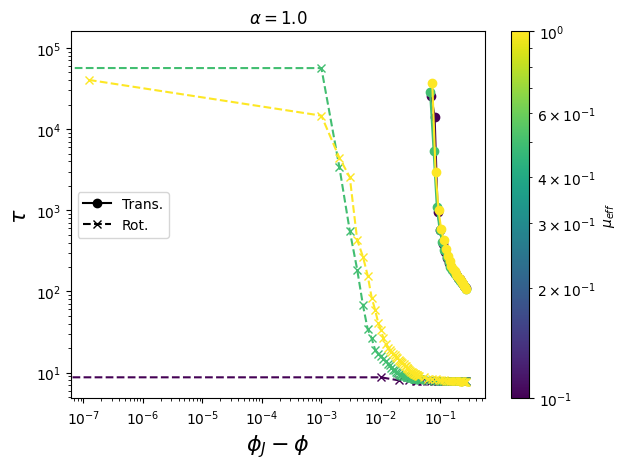

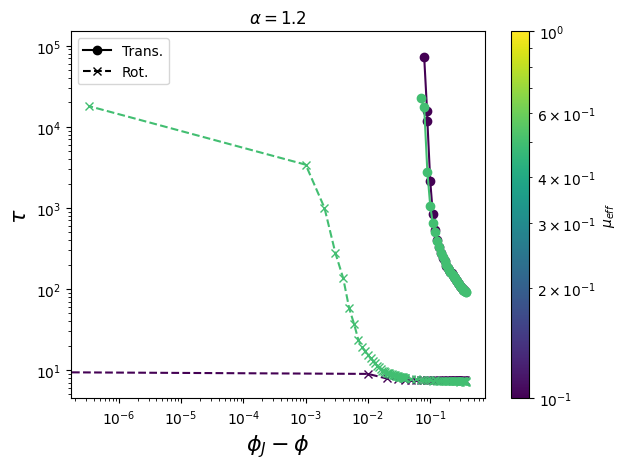

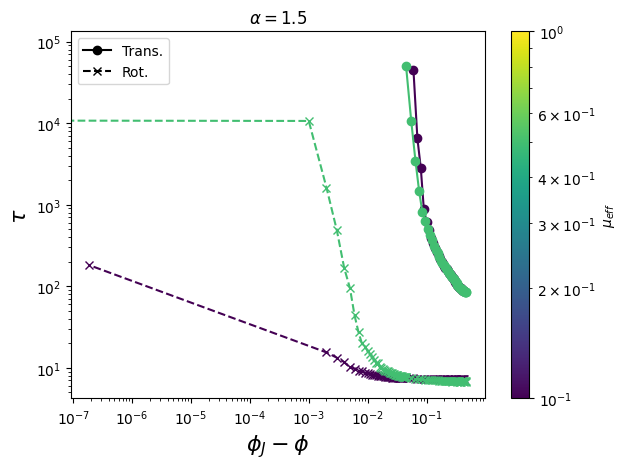

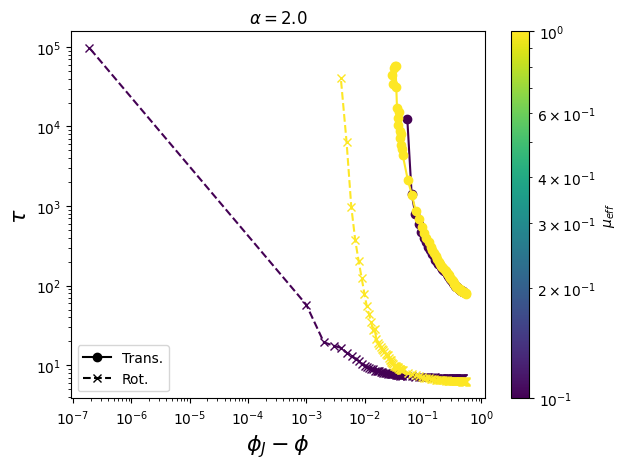

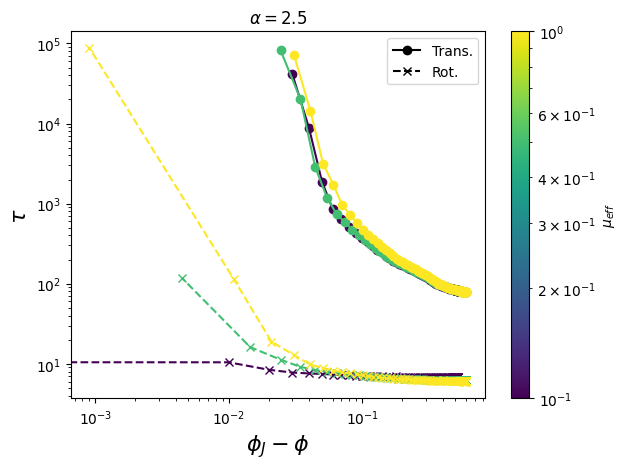

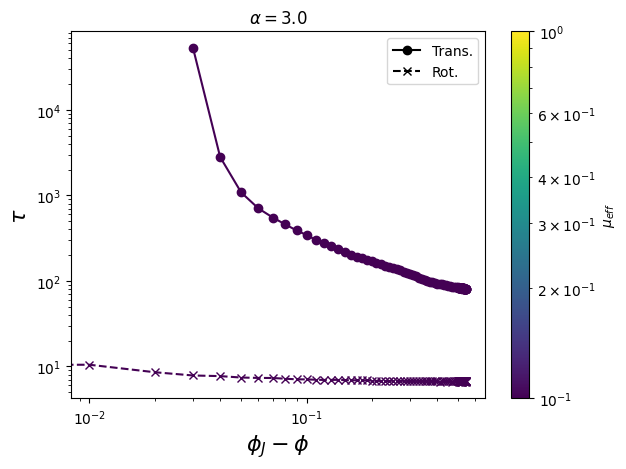

In [76]:
for alpha in pd.unique(tau_df.alpha):
    for mu in pd.unique(tau_df.mu):
        mask = (tau_df.alpha == alpha) & (tau_df.mu == mu)
        x = tau_df[mask].phi.values
        order = np.argsort(x)
        y = tau_df[mask].tau.values[order]
        y_r = tau_df[mask].tau_r.values[order]
        x = np.sort(x)
        mask = (jamming_data['mu'] == mu) & (jamming_data['alpha'] == alpha)
        if not np.any(mask):
            continue
        x_j = jamming_data['phi_j'][mask]
        plt.plot(x_j - x, y, c=cmap(mu_norm(mu)), marker='o')
        plt.plot(x_j - x, y_r, c=cmap(mu_norm(mu)), marker='x', linestyle='--')
    plt.plot([], [], marker='o', label='Trans.', c='k')
    plt.plot([], [], marker='x', linestyle='--', label='Rot.', c='k')
    plt.legend()
    plt.xlabel(r'$\phi_J - \phi$', fontsize=16)
    plt.ylabel(r'$\tau$', fontsize=16)
    plt.xscale('log')
    plt.yscale('log')
    plt.title(fr'$\alpha=${alpha}')
    sm = plt.cm.ScalarMappable(norm=mu_norm, cmap=cmap)
    sm.set_array(pd.unique(tau_df.mu))
    cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\mu_{eff}$')
    plt.tight_layout()
    plt.show()

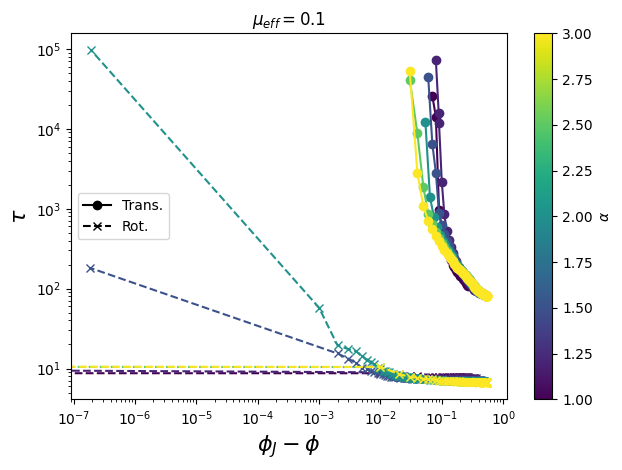

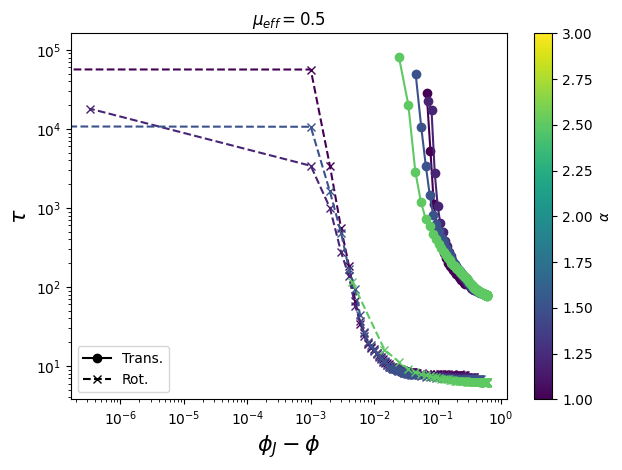

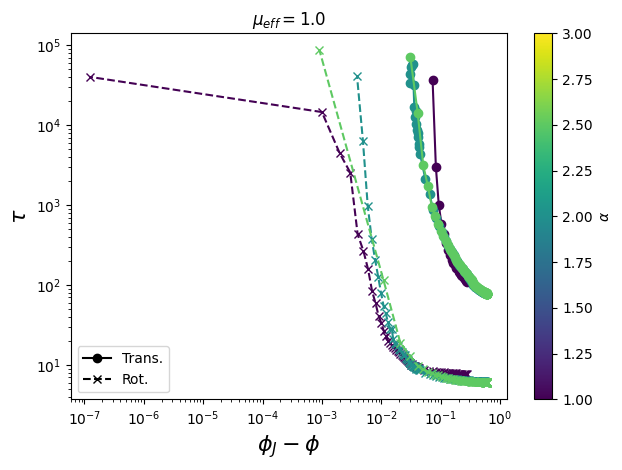

In [79]:
for mu in pd.unique(tau_df.mu):
    for alpha in pd.unique(tau_df.alpha):
        mask = (tau_df.alpha == alpha) & (tau_df.mu == mu)
        x = tau_df[mask].phi.values
        order = np.argsort(x)
        y = tau_df[mask].tau.values[order]
        y_r = tau_df[mask].tau_r.values[order]
        x = np.sort(x)
        mask = (jamming_data['mu'] == mu) & (jamming_data['alpha'] == alpha)
        if not np.any(mask):
            continue
        x_j = jamming_data['phi_j'][mask]
        plt.plot(x_j - x, y, c=cmap(alpha_norm(alpha)), marker='o')
        plt.plot(x_j - x, y_r, c=cmap(alpha_norm(alpha)), marker='x', linestyle='--')
    plt.plot([], [], marker='o', label='Trans.', c='k')
    plt.plot([], [], marker='x', linestyle='--', label='Rot.', c='k')
    plt.legend()
    plt.xlabel(r'$\phi_J - \phi$', fontsize=16)
    plt.ylabel(r'$\tau$', fontsize=16)
    plt.xscale('log')
    plt.yscale('log')
    plt.title(fr'$\mu_{{eff}}=${mu}')
    sm = plt.cm.ScalarMappable(norm=alpha_norm, cmap=cmap)
    sm.set_array(pd.unique(tau_df.alpha))
    cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\alpha$')
    plt.tight_layout()
    plt.show()

In [75]:
# plot against phi - phi_j

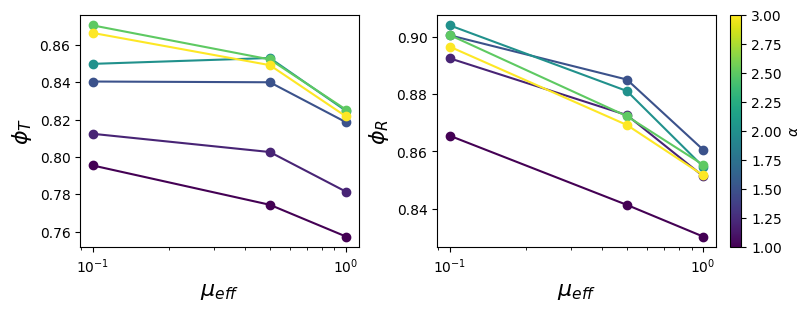

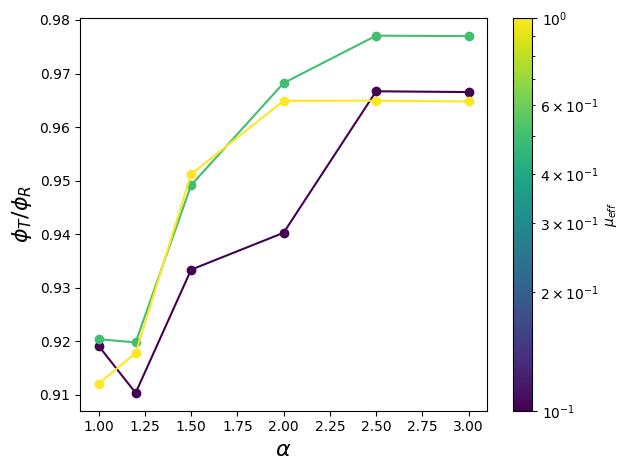

In [78]:
phi_c_df = {
    'alpha': [],
    'mu': [],
    'phi_T': [],
    'phi_R': [],
}
for alpha in pd.unique(tau_df.alpha):
    for mu in pd.unique(tau_df.mu):
        mask = (tau_df.alpha == alpha) & (tau_df.mu == mu)
        x = tau_df[mask].phi.values
        order = np.argsort(x)
        y = tau_df[mask].tau.values[order]
        y_r = tau_df[mask].tau_r.values[order]
        x = np.sort(x)

        phi_c_df['phi_T'].append(x[np.nanargmax(y)])
        phi_c_df['phi_R'].append(x[np.nanargmax(y_r)])
        phi_c_df['alpha'].append(alpha)
        phi_c_df['mu'].append(mu)
phi_c_df = pd.DataFrame(phi_c_df)

fig, ax = plt.subplots(1, 2, figsize=(8, 3), constrained_layout=True)
for alpha in pd.unique(phi_c_df.alpha):
    mask = (phi_c_df.alpha == alpha)
    x = phi_c_df.mu[mask].values
    order = np.argsort(x)
    y = phi_c_df.phi_T[mask].values[order]
    y_r = phi_c_df.phi_R[mask].values[order]
    x = x[order]
    ax[0].plot(x, y, marker='o', c=cmap(alpha_norm(alpha)))
    ax[1].plot(x, y_r, marker='o', c=cmap(alpha_norm(alpha)))
for a in ax:
    a.set_xscale('log')
    a.set_xlabel(r'$\mu_{eff}$', fontsize=16)
ax[0].set_ylabel(r'$\phi_T$', fontsize=16)
ax[1].set_ylabel(r'$\phi_R$', fontsize=16)
sm = plt.cm.ScalarMappable(norm=alpha_norm, cmap=cmap)
sm.set_array(pd.unique(phi_c_df.alpha))
cbar = plt.colorbar(sm, ax=ax[-1], label=r'$\alpha$')
plt.show()

for mu in pd.unique(phi_c_df.mu):
    mask = (phi_c_df.mu == mu)
    x = phi_c_df.alpha[mask].values
    order = np.argsort(x)
    y = phi_c_df.phi_T[mask].values[order]
    y_r = phi_c_df.phi_R[mask].values[order]
    x = x[order]
    plt.plot(x, y / y_r, marker='o', c=cmap(mu_norm(mu)))
plt.xlabel(r'$\alpha$', fontsize=16)
plt.ylabel(r'$\phi_T / \phi_R$', fontsize=16)
sm = plt.cm.ScalarMappable(norm=mu_norm, cmap=cmap)
sm.set_array(pd.unique(phi_c_df.mu))
cbar = plt.colorbar(sm, ax=plt.gca(), label=r'$\mu_{eff}$')
plt.tight_layout()
plt.savefig('TR-ratio-convergence.png', dpi=600)
plt.show()

/var/folders/f5/gw8thzr169xd6l47yn540sf80000gn/T/ipykernel_28622/1507478513.py:6: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(mu, jamming_data['phi_j'][mask], c=cmap(alpha_norm(alpha)))


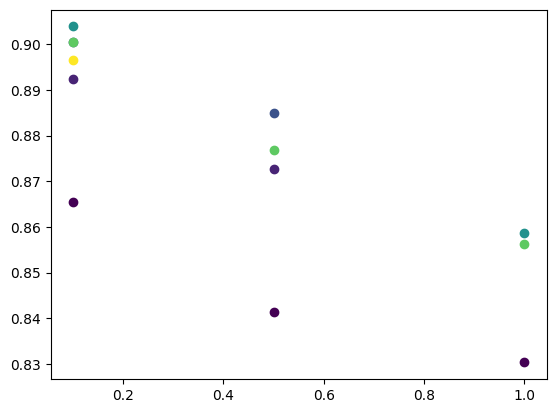

In [ ]:
for alpha in np.unique(jamming_data['alpha']):
    for mu in np.unique(jamming_data['mu']):
        mask = (jamming_data['mu'] == mu) & (jamming_data['alpha'] == alpha)
        if not np.any(mask):
            continue
        plt.scatter(mu, jamming_data['phi_j'][mask], c=cmap(alpha_norm(alpha)))